# Tuần 5: S-Learner (Single Model Learner)
Giải quyết bài toán cá nhân hóa khuyến mãi bằng thuật toán S-Learner. Nhằm tối ưu hóa AUUC và làm mượt Qini Curve.


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)


## 1. Chuẩn bị Dữ liệu (Toàn hệ thống)


In [2]:
# Load data
df = pd.read_csv('../../../data/processed/segmented_simulation_data.csv')
df['is_credit_card'] = (df['payment_type'] == 1).astype(int)

print(f"Tổng số lượng khách hàng toàn hệ thống: {len(df)}")

features = ['age', 'is_urban', 'preferred_hour', 'is_rush_hour', 'is_airport_trip', 'is_rain_rider', 'is_weekend_rider', 'is_credit_card', 'passenger_count', 'monthly_rides_history', 'recency_days']
X = df[features]
y = df['Y_rand']
T = df['treatment_rand']

X_train_val, X_test, y_train_val, y_test, T_train_val, T_test = train_test_split(X, y, T, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val, T_train, T_val = train_test_split(X_train_val, y_train_val, T_train_val, test_size=0.25, random_state=42)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")


Tổng số lượng khách hàng toàn hệ thống: 20000
Train size: 12000 | Val size: 4000 | Test size: 4000


## 2. Huấn luyện S-Learner


In [3]:
# S-Learner coi Treatment như một biến đầu vào bình thường
X_train_s = X_train.copy()
X_train_s['Treatment'] = T_train

X_val_s = X_val.copy()
X_val_s['Treatment'] = T_val

# Huấn luyện DUY NHẤT 1 mô hình
s_learner = xgb.XGBRegressor(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=4, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    early_stopping_rounds=15,
    min_child_weight=5,
    reg_lambda=1.0
)

s_learner.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)

print(f"S-Learner RMSE trên tập Val: {np.sqrt(mean_squared_error(y_val, s_learner.predict(X_val_s))):.3f}")


S-Learner RMSE trên tập Val: 6.314


## 3. Dự đoán CATE (Uplift Score)


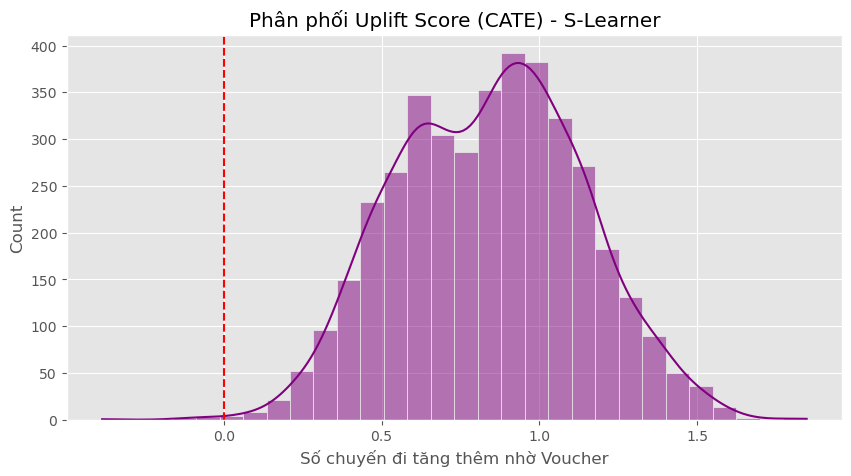

In [4]:
# Dự đoán giả lập cho tập Test
X_test_1 = X_test.copy()
X_test_1['Treatment'] = 1

X_test_0 = X_test.copy()
X_test_0['Treatment'] = 0

pred_1 = s_learner.predict(X_test_1)
pred_0 = s_learner.predict(X_test_0)

cate_pred = pred_1 - pred_0

df_res = pd.DataFrame({
    'y_true': y_test,
    'T': T_test,
    'pred_1': pred_1,
    'CATE_pred': cate_pred,
    'user_avg_fare': df.loc[X_test.index, 'avg_fare_per_trip'].values,
    'monthly_rides_history': X_test['monthly_rides_history'].values,
    'age': X_test['age'].values,
    'recency_days': X_test['recency_days'].values,
    'persona': df.loc[X_test.index, 'persona'].values
})

plt.figure(figsize=(10, 5))
sns.histplot(df_res['CATE_pred'], bins=30, kde=True, color='purple')
plt.title('Phân phối Uplift Score (CATE) - S-Learner')
plt.xlabel('Số chuyến đi tăng thêm nhờ Voucher')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()


## 4. Đánh giá Mô hình (Qini Curve)


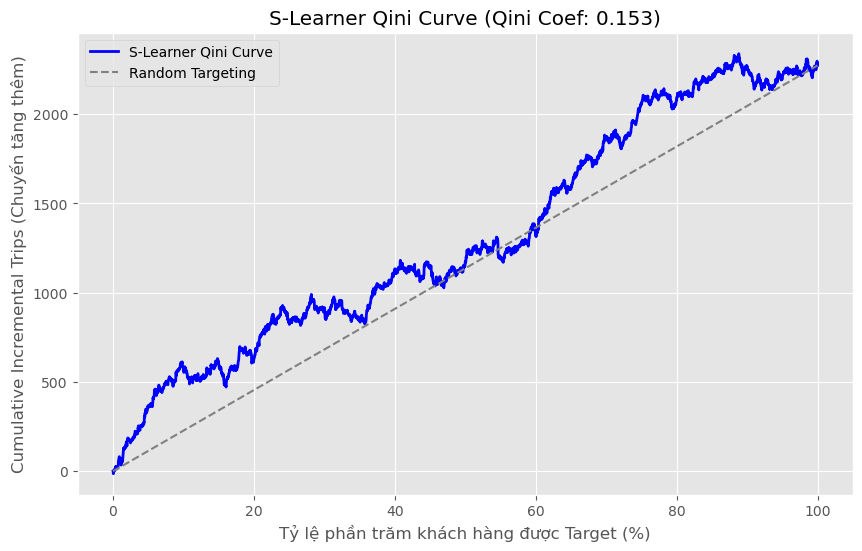

In [5]:
def qini_curve(y_true, T, CATE_pred):
    df_sorted = pd.DataFrame({'y_true': y_true, 'T': T, 'CATE_pred': CATE_pred}).sort_values(by='CATE_pred', ascending=False)
    df_sorted['T_cumsum'] = df_sorted['T'].cumsum()
    df_sorted['C_cumsum'] = (~df_sorted['T'].astype(bool)).astype(int).cumsum()
    df_sorted['Y_T_cumsum'] = (df_sorted['y_true'] * df_sorted['T']).cumsum()
    df_sorted['Y_C_cumsum'] = (df_sorted['y_true'] * (~df_sorted['T'].astype(bool)).astype(int)).cumsum()
    df_sorted['Qini'] = df_sorted['Y_T_cumsum'] - df_sorted['Y_C_cumsum'] * (df_sorted['T_cumsum'] / df_sorted['C_cumsum'])
    
    total_T = df_sorted['T'].sum()
    total_C = (~df_sorted['T'].astype(bool)).astype(int).sum()
    overall_uplift = df_sorted['Y_T_cumsum'].iloc[-1] - df_sorted['Y_C_cumsum'].iloc[-1] * (total_T / total_C)
    df_sorted['Random_Qini'] = np.linspace(0, overall_uplift, len(df_sorted))
    
    return df_sorted

df_qini = qini_curve(df_res['y_true'], df_res['T'], df_res['CATE_pred'])

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
auuc_model = np.trapezoid(df_qini['Qini'], dx=1)
auuc_random = np.trapezoid(df_qini['Random_Qini'], dx=1)
auuc = (auuc_model - auuc_random) / auuc_random

plt.figure(figsize=(10, 6))
plt.plot(np.linspace(0, 100, len(df_qini)), df_qini['Qini'], label='S-Learner Qini Curve', color='blue', linewidth=2)
plt.plot(np.linspace(0, 100, len(df_qini)), df_qini['Random_Qini'], label='Random Targeting', color='gray', linestyle='--')
plt.title(f'S-Learner Qini Curve (Qini Coef: {auuc:.3f})')
plt.xlabel('Tỷ lệ phần trăm khách hàng được Target (%)')
plt.ylabel('Cumulative Incremental Trips (Chuyến tăng thêm)')
plt.legend()
plt.show()


## 5. Tối ưu hóa Lợi nhuận & Insights


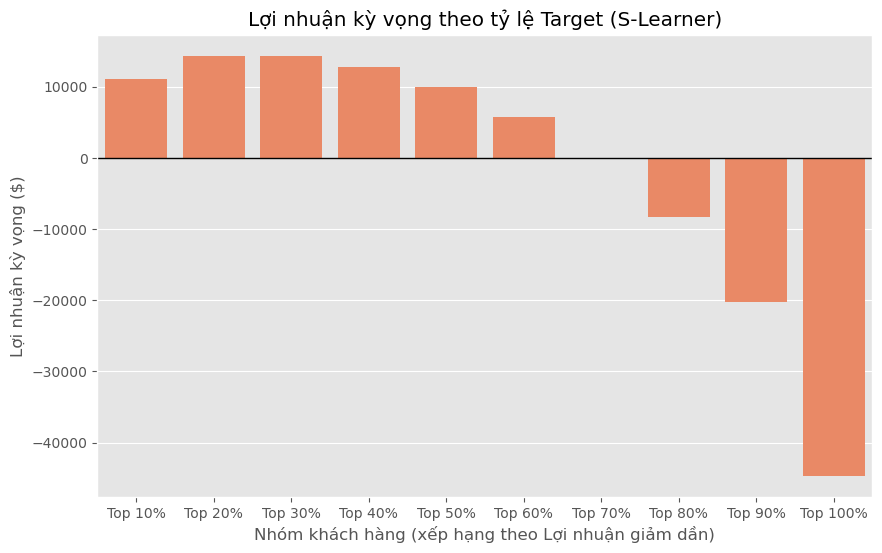

Lợi nhuận nếu phát Voucher đại trà (Top 100%): $-44,640.06
Lợi nhuận nếu chỉ phát Voucher cho Top 30% KH tốt nhất: $14,338.87

--- THÀNH PHẦN PERSONA TRONG TOP 30% LỢI NHUẬN NHẤT ---
persona
Suburban Cash       54.6
Suburban Card       26.3
Urban Regulars      14.2
Rain Riders          4.2
Airport Business     0.6
Name: proportion, dtype: float64

--- CHÂN DUNG KHÁCH HÀNG (TOP 30% vs 70%) ---
                       age  monthly_rides_history  recency_days  user_avg_fare
Top 30% (Target)     32.94                   0.59         11.03          28.10
Bottom 70% (Ignore)  28.71                   4.96          5.68          25.54


In [6]:
cost_per_ride = df_res['user_avg_fare'] * 0.15
df_res['Expected_Profit'] = (df_res['CATE_pred'] * df_res['user_avg_fare']) - (df_res['pred_1'] * cost_per_ride)
df_sorted = df_res.sort_values(by='Expected_Profit', ascending=False).copy()

k_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
profits = []

for k in k_values:
    n_target = int(len(df_sorted) * (k / 100))
    target_group = df_sorted.iloc[:n_target]
    total_profit = target_group['Expected_Profit'].sum()
    profits.append(total_profit)

plt.figure(figsize=(10, 6))
sns.barplot(x=[f'Top {k}%' for k in k_values], y=profits, color='coral')
plt.axhline(0, color='black', linewidth=1)
plt.title('Lợi nhuận kỳ vọng theo tỷ lệ Target (S-Learner)')
plt.xlabel('Nhóm khách hàng (xếp hạng theo Lợi nhuận giảm dần)')
plt.ylabel('Lợi nhuận kỳ vọng ($)')
plt.show()

top_100_profit = profits[-1]
top_30_profit = profits[2]
print(f"Lợi nhuận nếu phát Voucher đại trà (Top 100%): ${top_100_profit:,.2f}")
print(f"Lợi nhuận nếu chỉ phát Voucher cho Top 30% KH tốt nhất: ${top_30_profit:,.2f}")

top_30_group = df_sorted.iloc[:int(len(df_sorted)*0.30)]
bottom_70_group = df_sorted.iloc[int(len(df_sorted)*0.30):]

print("\n--- THÀNH PHẦN PERSONA TRONG TOP 30% LỢI NHUẬN NHẤT ---")
print(top_30_group['persona'].value_counts(normalize=True).round(3) * 100)

print("\n--- CHÂN DUNG KHÁCH HÀNG (TOP 30% vs 70%) ---")
profile = pd.DataFrame({
    'Top 30% (Target)': top_30_group[['age', 'monthly_rides_history', 'recency_days', 'user_avg_fare']].mean(),
    'Bottom 70% (Ignore)': bottom_70_group[['age', 'monthly_rides_history', 'recency_days', 'user_avg_fare']].mean()
}).T
print(profile.round(2))
